# Option pricing - Black-Scholes and Geometric Brownian Motion

## Importing libraries

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

# Importing Data and Calculating Volatility

In [2]:
# Pulling stock data


aapl = yf.Ticker("AAPL").history(period = "2y")
tsla = yf.Ticker("TSLA").history(period = "2y")

In [3]:
# Splitting at the same date for both data sets to allow for a fair comparison when pricing options later on
# Split data gives around 75% of data for calculating volatility
cutoff_date = "2026-03-13"

# Split data from both stocks 

aapl_vol_data = aapl[aapl.index < cutoff_date]
aapl_test_data = aapl[aapl.index >= cutoff_date]

tsla_vol_data = tsla[tsla.index < cutoff_date]
tsla_test_data = tsla[tsla.index >= cutoff_date]

In [4]:
# Calculate historical volatility data, begin by calculating daily log returns
# Create empty array of len - 1 as the first day of data doesnt have a log return 
aapl_log_returns = np.empty(len(aapl_vol_data) - 1, dtype = float)

# Loop through all day and calculate and store log returns for Apple then Tesla

for i in range(1, len(aapl_vol_data)):
    aapl_log_returns[i-1] = np.log(aapl_vol_data.iloc[i]["Close"] / aapl_vol_data.iloc[i-1]["Close"])

# Find volatility by taking standard deviation of daily log returns and times by sqrt of 252 (trading days in a year) to reflect yearly volatility

aapl_volatility = np.std(aapl_log_returns) * np.sqrt(252)


# Calculate for Tesla

tsla_log_returns = np.empty(len(tsla_vol_data) - 1, dtype = float)

for i in range(1, len(tsla_vol_data)):
    tsla_log_returns[i-1] = np.log(tsla_vol_data.iloc[i]["Close"] / tsla_vol_data.iloc[i-1]["Close"])

tsla_volatility = np.std(tsla_log_returns) * np.sqrt(252)

print(f"Estimated Apple volatility: {aapl_volatility:.4f}")
print(f"Estimated Tesla volatility: {tsla_volatility:.4f}")

Estimated Apple volatility: 0.2908
Estimated Tesla volatility: 0.6222


# Option Pricing Formulas

In [5]:
# Defining black scholes call price function
# d1 measures how far the current price is above the strike price after adjusting for drift 
# d2 measures the same but at the time of expiry 

def scholes_call(pricing_data):
    s0 = pricing_data["s0"]  #Current price of stock
    k = pricing_data["k"]    #Strike price
    t = pricing_data["t"]    #Time to expiration
    r = pricing_data["r"]    #Risk free interest rate
    v = pricing_data["v"]    #Volatility

    d1 = (np.log(s0/k) + (r + (v**2)/2)*t) / (v * np.sqrt(t))
    d2 = d1 - (v * np.sqrt(t))

    return (s0 * sp.stats.norm.cdf(d1)) - (k * np.exp(- r * t) * sp.stats.norm.cdf(d2))

# Defining black scholes put price function

def scholes_put(pricing_data):
    s0 = pricing_data["s0"]  #Current price of stock
    k = pricing_data["k"]    #Strike price
    t = pricing_data["t"]    #Time to expiration
    r = pricing_data["r"]    #Risk free interest rate
    v = pricing_data["v"]    #Volatility

    d1 = (np.log(s0/k) + (r + (v**2)/2)*t) / (v * np.sqrt(t))
    d2 = d1 - (v * np.sqrt(t))

    return (k * np.exp(-r *  t) * sp.stats.norm.cdf(-d2)) - (s0 * sp.stats.norm.cdf(-d1))
    

In [6]:
# Defining calculations for call and put options when using geometric brownian motion terminal equation with monte carlo simulation

def gbm_call_price(pricing_data, n_sims):
    s0 = pricing_data["s0"]  #Current price of stock
    k = pricing_data["k"]    #Strike price
    t = pricing_data["t"]    #Time to expiration
    r = pricing_data["r"]    #Risk free interest rate
    v = pricing_data["v"]    #Volatility
    z = np.random.normal(0, 1, n_sims)

    #s_t --> collection of final stock prices generated by brownian motion
    s_t = gbm_terminal(s0, r, v, t, z)

    # Calculate payoff for each simualted price, average then discount back to present
    return np.mean(np.maximum(s_t - k, 0)) * np.exp(-r * t)

def gbm_put_price(pricing_data, n_sims):
    s0 = pricing_data["s0"]  #Current price of stock
    k = pricing_data["k"]    #Strike price
    t = pricing_data["t"]    #Time to expiration
    r = pricing_data["r"]    #Risk free interest rate
    v = pricing_data["v"]    #Volatility
    z = np.random.normal(0, 1, n_sims)

    #s_t --> collection of final stock prices generated by brownian motion
    s_t = gbm_terminal(s0, r, v, t, z)

    # Calculate payoff for each simualted price, average then discount back to present
    return np.mean(np.maximum(k - s_t, 0)) * np.exp(-r * t)

# Defining geometric brownian motion temrinal equation

def gbm_terminal(s0, r, v, t, z):
    return s0 * np.exp(((r - 0.5*v**2) * t) + v * np.sqrt(t) * z)

In [7]:
# Testing/Verifying formulas with "Benchmark" parameters expected prices: Call: 8.92, Put: 6.94

pricing_data = {
"s0": 100,
"r": 0.02,
"v": 0.2,
"t": 1,
"k": 100
}
n_sims = 10**6
print(f"GBM calculated call price: {gbm_call_price(pricing_data, n_sims):.4f}")
print(f"Scholes calculated call price: {scholes_call(pricing_data):.4f}")
print(f"GBM calculated put price: {gbm_put_price(pricing_data, n_sims):.4f}")
print(f"Scholes calculated put price: {scholes_put(pricing_data):.4f}")

GBM calculated call price: 8.9225
Scholes calculated call price: 8.9160
GBM calculated put price: 6.9301
Scholes calculated put price: 6.9359


# GBM Monte Carlo Simualations

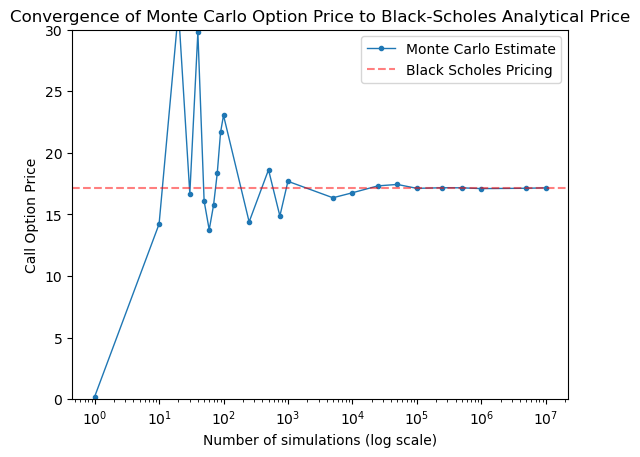

In [8]:
# Demonstrating why we use a large number of simulations when calculating option prices with Geometric Brownian motion 

n_sims = np.array([1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 250, 500, 750, 1000, 5000, 10000, 25000, 50000, 100000, 250000, 500000, 1000000, 5000000, 10000000])
pricing_data = {
"s0": 100,
"r": 0.03,
"v": 0.4,
"t": 1,
"k": 100
}

call_prices = np.empty(len(n_sims))
for i in range(len(n_sims)):    
    call_prices[i] = gbm_call_price(pricing_data, n_sims[i])

plt.plot(n_sims, call_prices, linewidth = 1, label = "Monte Carlo Estimate", marker = ".")
plt.xscale("log")
plt.axhline(y = scholes_call(pricing_data), color = "r", linestyle = "--", alpha = 0.5, label = "Black Scholes Pricing")
plt.xlabel("Number of simulations (log scale)")
plt.ylabel("Call Option Price")
plt.ylim(0, 30)
plt.title("Convergence of Monte Carlo Option Price to Black-Scholes Analytical Price")
plt.legend()
plt.show()

Monte Carlo pricing works by simulating future stock prices using GBM. Each simulation gives a possible payoff. The option price is then calculated by averaging all the possible payoffs. As GBM uses a random normal distribution which creates randomness, we use a large number of simualtions to reduce sampling error and therefore converge on the analytical option price (Black-Scholes) as seen in the graph.

# Pricing Tesla and Apple Options

In [9]:
# Set pricing data for Apple and Tesla

aapl_pricing_data ={
"s0": aapl_test_data.iloc[0]["Close"],
"r": 0.037,   # 12/3/26 US 3 month treasury bill yield
"v": aapl_volatility,
"t": 0.5,     # 6 month expiry 
"k": aapl_test_data.iloc[0]["Close"]
}

tsla_pricing_data ={
"s0": tsla_test_data.iloc[0]["Close"],
"r": 0.037,   # 12/3/26 US 3 month treasury bill yield
"v": tsla_volatility,
"t": 0.5,     # 6 month expiry 
"k": tsla_test_data.iloc[0]["Close"]
}

n_sims = 10**6

In [10]:
# Calculate options pricing and present in table

# Black scholes prices
aapl_scholes_call = scholes_call(aapl_pricing_data)
aapl_scholes_put = scholes_put(aapl_pricing_data)
tsla_scholes_call = scholes_call(tsla_pricing_data)
tsla_scholes_put = scholes_put(tsla_pricing_data)

# GBM pricing
aapl_gbm_call = gbm_call_price(aapl_pricing_data, n_sims)
aapl_gbm_put = gbm_put_price(aapl_pricing_data, n_sims)
tsla_gbm_call = gbm_call_price(tsla_pricing_data, n_sims)
tsla_gbm_put = gbm_put_price(tsla_pricing_data, n_sims)


# Present prices in Pandas Data frame
aapl_tsla_results = [
    {"Stock": "Apple", "Option Type": "Call", "Black-Scholes": aapl_scholes_call, "GBM": aapl_gbm_call},
    {"Stock": "Apple", "Option Type": "Put", "Black-Scholes": aapl_scholes_put, "GBM": aapl_gbm_put},
    {"Stock": "Tesla", "Option Type": "Call", "Black-Scholes": tsla_scholes_call, "GBM": tsla_gbm_call},
    {"Stock": "Tesla", "Option Type": "Put", "Black-Scholes": tsla_scholes_put, "GBM": tsla_gbm_put}
]

aapl_tsla_results_df = pd.DataFrame(aapl_tsla_results)
aapl_tsla_results_df.round(2)

,Stock,Option Type,Black-Scholes,GBM
0,Apple,Call,22.63,22.61
1,Apple,Put,18.05,18.09
2,Tesla,Call,71.13,71.13
3,Tesla,Put,63.96,63.94


# GBM Paths

In [11]:
# Modelling GBM paths 
n_steps = 126 # A step for each trading day in half a year
n_paths = 50 # Simulate 50 paths
t = 0.5 # Simulate stock prices over a 6 month period
dt = t / n_steps

# Define variables for each stock
aapl_pricing_data ={
"s0": aapl_test_data.iloc[0]["Close"],
"r": 0.037,   # 12/3/26 US 3 month treasury bill yield
"v": aapl_volatility, 
"k": aapl_test_data.iloc[0]["Close"]
}

tsla_pricing_data ={
"s0": tsla_test_data.iloc[0]["Close"],
"r": 0.037,   # 12/3/26 US 3 month treasury bill yield
"v": tsla_volatility,
"k": tsla_test_data.iloc[0]["Close"]
}


# Create array to store stock price at each step for each path and set the first value of each path to s0
aapl_paths = np.zeros((n_paths, n_steps), dtype = float)
tsla_paths = np.zeros((n_paths, n_steps), dtype = float)
aapl_paths[:, 0] = aapl_pricing_data["s0"]
tsla_paths[:, 0] = tsla_pricing_data["s0"]

# Store the GBM time step equation under a function

def gbm_time_step(st, r, v, dt):
    # st - Current stock price
    # r - Risk free rate
    # v - Volatility
    # dt - Time step
    z = np.random.normal(0, 1) 

    return (st * np.exp( (r - 0.5*v**2) * dt + v*np.sqrt(dt)*z )) # Return the next price of the stock

In [12]:
# Simulate the paths for each stock
# Set constant variables - Risk free rate and time step as well as paths and steps

r = 0.037
dt = t/n_steps
n_paths = 50
n_steps = 126

# Apple paths - set volatility to the vol i calculated and remains constant
v = aapl_pricing_data["v"]

for path in range (n_paths):
    for step in range (n_steps - 1):
        st = aapl_paths[path, step]
        # Set the next stock price as the price returned by the GBM time step function
        aapl_paths[path, step + 1] = gbm_time_step(st, r, v, dt)

# Tesla paths repeat the process
v = tsla_pricing_data["v"]

for path in range (n_paths):
    for step in range (n_steps - 1):
        st = tsla_paths[path, step]
        tsla_paths[path, step + 1] = gbm_time_step(st, r, v, dt)

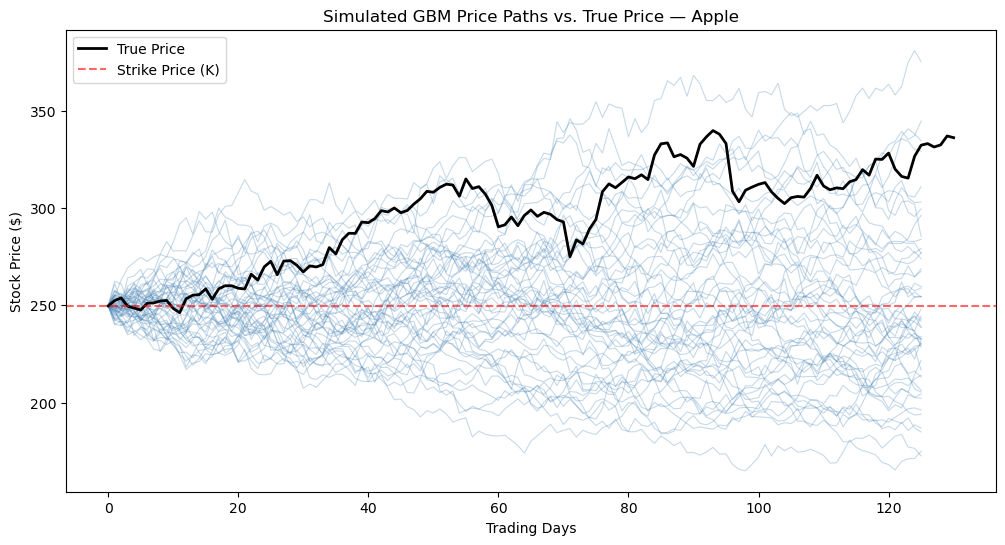

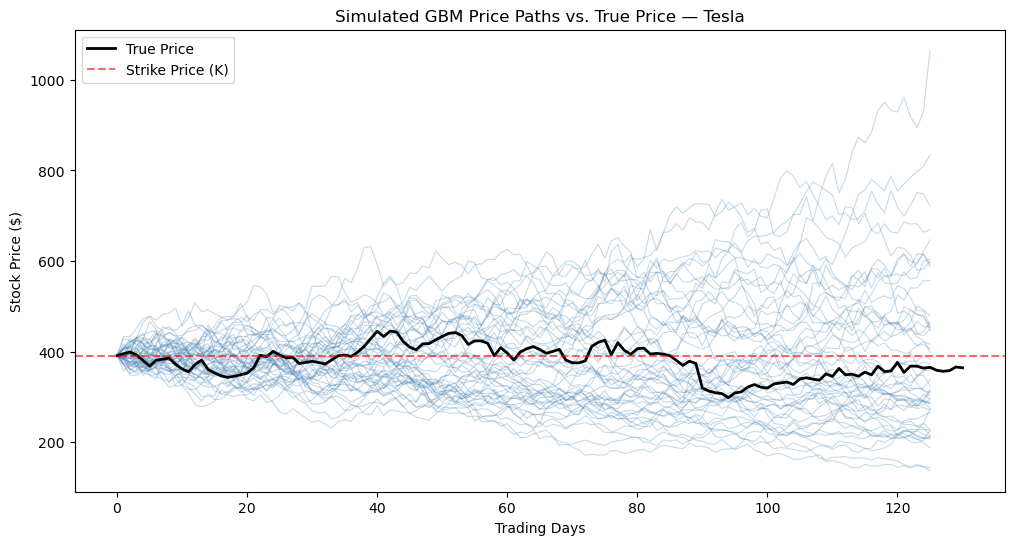

In [13]:
# Visualise paths

# Apple stock

plt.figure(figsize=(12, 6))

# Plot each simulated path 
for path in range(n_paths):
    plt.plot(aapl_paths[path, :], color="steelblue", alpha=0.3, linewidth=0.8)

# Show real stock prcies
plt.plot(aapl_test_data["Close"].values, color="black", linewidth=2, label="True Price")

# Mark strike price
plt.axhline(y=aapl_pricing_data["k"], color="red", linestyle="--", alpha=0.6, label="Strike Price (K)")

plt.xlabel("Trading Days")
plt.ylabel("Stock Price ($)")
plt.title("Simulated GBM Price Paths vs. True Price — Apple")
plt.legend()
plt.show()


# For Tesla stock
plt.figure(figsize=(12, 6))

# Plot each simulated path 
for path in range(n_paths):
    plt.plot(tsla_paths[path, :], color="steelblue", alpha=0.3, linewidth=0.8)

# Show real stock prcies
plt.plot(tsla_test_data["Close"].values, color="black", linewidth=2, label="True Price")

# Mark strike price
plt.axhline(y=tsla_pricing_data["k"], color="red", linestyle="--", alpha=0.6, label="Strike Price (K)")

plt.xlabel("Trading Days")
plt.ylabel("Stock Price ($)")
plt.title("Simulated GBM Price Paths vs. True Price — Tesla")
plt.legend()
plt.show()

The graphs above show 50 simulated GBM stock price paths for both Apple and Tesla with the strike price in red and the real price of the stock pulled from yfinance overlayed with a black line. Looking at both of the graphs the real stock prices fall well within my simulated stock price paths therefore indicating that my estimated volatility is relatively accurate. I can also further validate by calculating the true volatility over the test period ie the period used in the graph using closing prices from yfinance. 

# Estimated Volatility vs True Volatility

In [14]:
# Calculating true volatility of each stock and comparing with my estimated volatility

aapl_true_log_returns = np.zeros(len(aapl_test_data) - 1, dtype = float)
tsla_true_log_returns = np.zeros(len(tsla_test_data) - 1, dtype = float)

for i in range(1, len(aapl_test_data)):
    aapl_true_log_returns[i-1] = np.log(aapl_test_data.iloc[i]["Close"] / aapl_test_data.iloc[i-1]["Close"])

for i in range(1, len(tsla_test_data)):
    tsla_true_log_returns[i-1] = np.log(tsla_test_data.iloc[i]["Close"] / tsla_test_data.iloc[i-1]["Close"])

aapl_true_volatility = np.std(aapl_true_log_returns) * np.sqrt(252)
tsla_true_volatility = np.std(tsla_true_log_returns) * np.sqrt(252)

In [15]:
# Compare estimated and true volatility for both stocks

vol_results = [
    {"Stock": "Apple", "Estimated Volatility": aapl_volatility, "True Volatility": aapl_true_volatility, "% Difference": abs((aapl_volatility - aapl_true_volatility)/aapl_volatility*100)},
    {"Stock": "Tesla", "Estimated Volatility": tsla_volatility, "True Volatility": tsla_true_volatility, "% Difference": abs((tsla_volatility - tsla_true_volatility)/tsla_volatility*100)}
]

volatility_df = pd.DataFrame(vol_results)
volatility_df.round(4)

,Stock,Estimated Volatility,True Volatility,% Difference
0,Apple,0.2908,0.2725,6.2953
1,Tesla,0.6222,0.5041,18.9875


My estiamted voaltility for Apple was fairly accurate compared to the true volatility with only a 5% difference. 
However my Tesla estimated volatility was much higher than the True volatility by 18%. This is likely due to the period I used for my estimated volatility which included Teslas all time high led by event driven volatility. Combined with the companies first ever annual decline in vehicle deliveries led to large sways in stock prices and therefore a large volatility in my estimate. However, the test period had a relatively calm period with recovery from the fall in stock prices combined with a strong Q1 performance resulted in a lower volatility. <br>
Even though my estiamted volatility was noticeably higher I think my option prices are still accurate with the data I inputted.

# Effect of Volatility on GBM Paths

In [16]:
# Effect of volatility on GBM paths
# Return to benchmark pricing data however one set of paths will use v = 0.1 and the other uses 0.4

n_paths = 50
n_steps = 126
t = 0.5
dt = 0.5/n_steps
s0 = 100
r = 0.02

v_04_paths = np.zeros((n_paths, n_steps), dtype = float)
v_02_paths = np.zeros((n_paths, n_steps), dtype = float)

v_04_paths[:, 0] = s0
v_02_paths[:, 0] = s0

# Simulate v = 0.4 paths first
v = 0.4
for path in range (n_paths):
    for step in range (n_steps - 1):
        st = v_04_paths[path, step]
        v_04_paths[path, step + 1] = gbm_time_step(st, r, v, dt)


# Simulate v = 0.2 paths
v = 0.2
for path in range (n_paths):
    for step in range (n_steps - 1):
        st = v_02_paths[path, step]
        v_02_paths[path, step + 1] = gbm_time_step(st, r, v, dt)

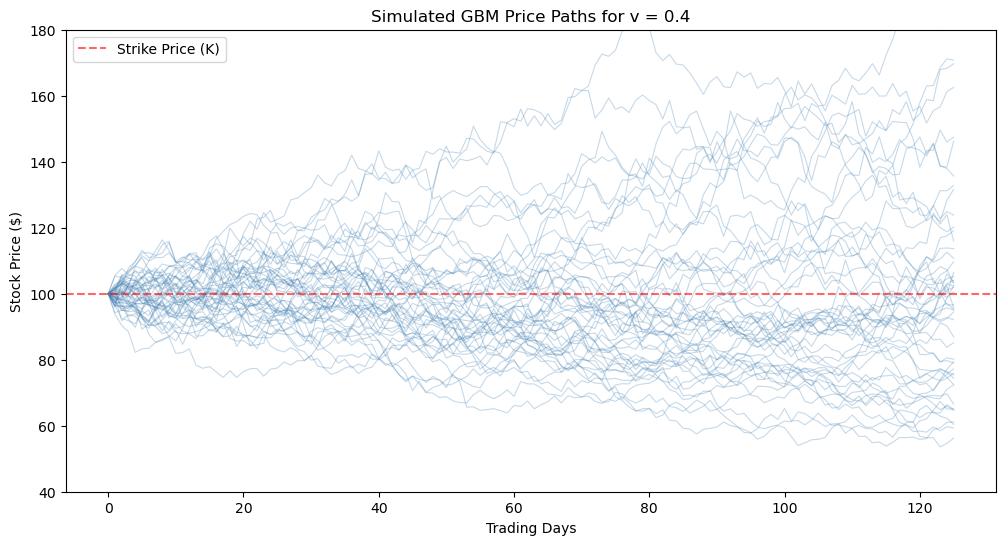

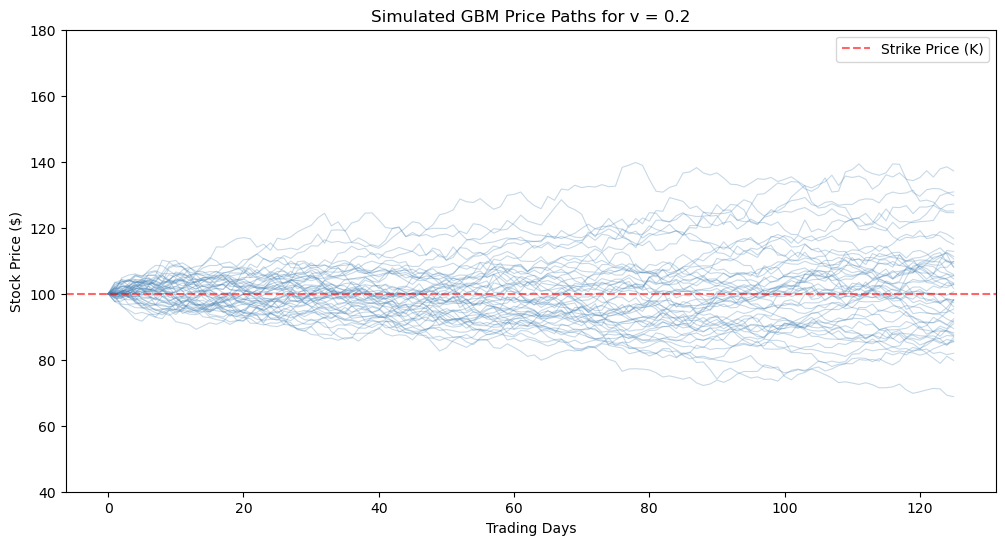

In [17]:
# Visualise both paths

plt.figure(figsize=(12, 6))

# Plot each simulated path 
for path in range(n_paths):
    plt.plot(v_04_paths[path, :], color="steelblue", alpha=0.3, linewidth=0.8)

# Mark strike price
plt.axhline(y = 100, color="red", linestyle="--", alpha=0.6, label="Strike Price (K)")

plt.xlabel("Trading Days")
plt.ylabel("Stock Price ($)")
plt.ylim(40, 180)
plt.title("Simulated GBM Price Paths for v = 0.4")
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))

# Plot each simulated path 
for path in range(n_paths):
    plt.plot(v_02_paths[path, :], color="steelblue", alpha=0.3, linewidth=0.8)

# Mark strike price
plt.axhline(y = 100, color="red", linestyle="--", alpha=0.6, label="Strike Price (K)")

plt.xlabel("Trading Days")
plt.ylabel("Stock Price ($)")
plt.ylim(40, 180)
plt.title("Simulated GBM Price Paths for v = 0.2")
plt.legend()
plt.show()

As seen in the graphs above, volatility has 2 main impacts on GBM price paths. A higher volatility will not only lead to larger daily fluctuations but will also result in a wider range of final stock prices due to the greater variations in price paths. We can also see this in the Apple vs Tesla prices where Tesla with the higher volatility fans out a lot more than Apple's simulated price paths.

# Greeks

As option prices arent fixed they change as the market shifts. The Greeks quantify these changes by how sensitive the option price is as an input changes while the rest are held constant. I measured 3 Greeks in my project:<br>
Delta - Measures the sensitivity in response to the stock price. For a call option it is between 0 and 1. For a put option delta is between -1 and 0.<br>
Gamma - Measures the rate at which delta changes. It peaks near the strike price where the options final payoff is most uncertain.<br>
Vega - Measures sensitivity to volatility, a higher volatility increases an option's value as volatility drives the spread of possible final stock prices.

To calculate Greeks we can use both an analytical apporach and finite differences:<br>
Analytical Greeks - This is only possible because Black-Scholes has a known formula to differentiate and give the exact Greek value.<br>
Finite Differences - This approach gives an approxiamate estimate by making a small nudge in 1 of the inputs and then captures the shift in the option price. We use finite differences whenever the pricing function doesn't have a closed-form formula otherwise it's best to sue Black-Scholes as they are faster to calculate and more accurate.

In [18]:
# Start by creating a function to calculate all 3 greeks (Delta, Gamma and Vega) analytically using Black-Scholes

def analytical_greeks(pricing_data):
    s0 = pricing_data["s0"] # Current stock price
    k = pricing_data["k"] # Strike price
    t = pricing_data["t"] # Time to expiry
    r = pricing_data["r"] # Risk free rate
    v = pricing_data["v"] # Volatility

    # Define d1 and d2 again
    d1 = (np.log(s0/k) + (r + 0.5*v**2) * t) / (v * np.sqrt(t))
    d2 = d1 - (v * np.sqrt(t))

    # Calculate delta for both call and put options
    delta_call = sp.stats.norm.cdf(d1)
    delta_put = sp.stats.norm.cdf(d1) - 1

    # Calculate gamma - same for both call and put options
    gamma = sp.stats.norm.pdf(d1) / (s0 * v * np.sqrt(t))

    # Calculate vega - same for cal and put options
    vega = sp.stats.norm.pdf(d1) * s0 * np.sqrt(t)

    return {
        "Delta - Call": delta_call,
        "Delta - Put": delta_put,
        "Gamma": gamma,
        "Vega": vega
    }

In [19]:
# Create a function to calculate greeks using finite difference
# Pricing data is already stored as a dictionary when its passed into the functionthat can be passed into the scholes and GBM pricing functions
# In order to calculate greeks using finite differences we also need a dictionary with price s0 + epsilom as well as v + epsilom
# We can take the pricing data dictionary and create 2 more dictionaries and add the epsiloms as needed

def scholes_finite_difference_greek(pricing_data, s0_eps, v_eps):
    pricing_up = pricing_data.copy()
    pricing_up["s0"] += s0_eps
    pricing_down = pricing_data.copy()
    pricing_down["s0"] -= s0_eps

    vol_up = pricing_data.copy()
    vol_up["v"] += v_eps
    vol_down = pricing_data.copy()
    vol_down["v"] -= v_eps

    delta_call = (scholes_call(pricing_up) - scholes_call(pricing_down)) / (2 * s0_eps)
    delta_put = (scholes_put(pricing_up) - scholes_put(pricing_down)) / (2 * s0_eps)

    gamma = (scholes_call(pricing_up) - (2 * scholes_call(pricing_data)) + scholes_call(pricing_down)) / (s0_eps ** 2)

    vega = (scholes_call(vol_up) - scholes_call(vol_down)) / (2 * v_eps)

    return{
        "Delta - Call": delta_call,
        "Delta - Put": delta_put,
        "Gamma": gamma,
        "Vega": vega
    }
    
    
# Create a function to calculate finite differences using GBM   

def gbm_finite_difference_greeks(pricing_data, s0_eps, v_eps):
    pricing_up = pricing_data.copy()
    pricing_up["s0"] += s0_eps
    pricing_down = pricing_data.copy()
    pricing_down["s0"] -= s0_eps

    vol_up = pricing_data.copy()
    vol_up["v"] += v_eps
    vol_down = pricing_data.copy()
    vol_down["v"] -= v_eps

    delta_call = (gbm_call_price(pricing_up, 10**7) - gbm_call_price(pricing_down, 10**7)) / (2 * s0_eps)
    delta_put = (gbm_put_price(pricing_up, 10**7) - gbm_put_price(pricing_down, 10**7)) / (2 * s0_eps)

    gamma = (gbm_call_price(pricing_up, 10**7) - (2 * gbm_call_price(pricing_data, 10**7)) + gbm_call_price(pricing_down, 10**7)) / (s0_eps ** 2)

    vega = (gbm_call_price(vol_up, 10**7) - gbm_call_price(vol_down, 10**7)) / (2 * v_eps)

    return{
        "Delta - Call": delta_call,
        "Delta - Put": delta_put,
        "Gamma": gamma,
        "Vega": vega
    }

In [20]:
# Testing functions with benchmark pricing data

s0_eps = 1
v_eps = 0.01

pricing_data = {
"s0": 100,
"r": 0.02,
"v": 0.2,
"t": 1,
"k": 100
}

bm_analytical_greeks = analytical_greeks(pricing_data)
bm_scholes_finite_greeks = scholes_finite_difference_greek(pricing_data, s0_eps, v_eps)
bm_gbm_finite_greeks = gbm_finite_difference_greeks(pricing_data, s0_eps, v_eps)

bm_greeks = [
    {"Greek": "Delta", "Option Type": "Call", "Analytical": bm_analytical_greeks["Delta - Call"], "Scholes Finite": bm_scholes_finite_greeks["Delta - Call"], "GBM Finite": bm_gbm_finite_greeks["Delta - Call"]},
    {"Greek": "Delta", "Option Type": "Put", "Analytical": bm_analytical_greeks["Delta - Put"], "Scholes Finite": bm_scholes_finite_greeks["Delta - Put"], "GBM Finite": bm_gbm_finite_greeks["Delta - Put"]},
    {"Greek": "Gamma", "Option Type": "Call, Put", "Analytical": bm_analytical_greeks["Gamma"], "Scholes Finite": bm_scholes_finite_greeks["Gamma"], "GBM Finite": bm_gbm_finite_greeks["Gamma"]},
    {"Greek": "Vega", "Option Type": "Call, Put", "Analytical": bm_analytical_greeks["Vega"], "Scholes Finite": bm_scholes_finite_greeks["Vega"], "GBM Finite": bm_gbm_finite_greeks["Vega"]}
]

bm_greeks_df = pd.DataFrame(bm_greeks)
print("Greeks - Benchmark Pricing data")
bm_greeks_df.round(4)

Greeks - Benchmark Pricing data


,Greek,Option Type,Analytical,Scholes Finite,GBM Finite
0,Delta,Call,0.5793,0.5792,0.5740
1,Delta,Put,-0.4207,-0.4208,-0.4237
2,Gamma,"Call, Put",0.0196,0.0195,0.0085
3,Vega,"Call, Put",39.1043,39.1036,38.9821


In [21]:
# Calculating and displaying Apple Greeks

s0_eps = 1
v_eps = 0.01

aapl_pricing_data ={
"s0": aapl_test_data.iloc[0]["Close"],
"r": 0.037,   # 12/3/26 US 3 month treasury bill yield
"v": aapl_volatility,
"t": 0.5,     # 6 month expiry 
"k": aapl_test_data.iloc[0]["Close"]
}

aapl_analytical_greeks = analytical_greeks(aapl_pricing_data)
aapl_scholes_finite_greeks = scholes_finite_difference_greek(aapl_pricing_data, s0_eps, v_eps)
aapl_gbm_finite_greeks = gbm_finite_difference_greeks(aapl_pricing_data, s0_eps, v_eps)

aapl_greeks = [
    {"Greek": "Delta", "Option Type": "Call", "Analytical": aapl_analytical_greeks["Delta - Call"], "Scholes Finite": aapl_scholes_finite_greeks["Delta - Call"], "GBM Finite": aapl_gbm_finite_greeks["Delta - Call"]},
    {"Greek": "Delta", "Option Type": "Put", "Analytical": aapl_analytical_greeks["Delta - Put"], "Scholes Finite": aapl_scholes_finite_greeks["Delta - Put"], "GBM Finite": aapl_gbm_finite_greeks["Delta - Put"]},
    {"Greek": "Gamma", "Option Type": "Call, Put", "Analytical": aapl_analytical_greeks["Gamma"], "Scholes Finite": aapl_scholes_finite_greeks["Gamma"], "GBM Finite": aapl_gbm_finite_greeks["Gamma"]},
    {"Greek": "Vega", "Option Type": "Call, Put", "Analytical": aapl_analytical_greeks["Vega"], "Scholes Finite": aapl_scholes_finite_greeks["Vega"], "GBM Finite": aapl_gbm_finite_greeks["Vega"]}
]

aapl_greeks_df = pd.DataFrame(aapl_greeks)
print("Greeks - Apple")
aapl_greeks_df.round(4)

Greeks - Apple


,Greek,Option Type,Analytical,Scholes Finite,GBM Finite
0,Delta,Call,0.5764,0.5764,0.5715
1,Delta,Put,-0.4236,-0.4236,-0.4308
2,Gamma,"Call, Put",0.0076,0.0076,-0.0098
3,Vega,"Call, Put",69.1352,69.1347,69.5059


In [22]:
# Calculating and displaying Tesla Greeks

s0_eps = 1
v_eps = 0.01

tsla_pricing_data ={
"s0": tsla_test_data.iloc[0]["Close"],
"r": 0.037,   # 12/3/26 US 3 month treasury bill yield
"v": tsla_volatility,
"t": 0.5,     # 6 month expiry 
"k": tsla_test_data.iloc[0]["Close"]
}

tsla_analytical_greeks = analytical_greeks(tsla_pricing_data)
tsla_scholes_finite_greeks = scholes_finite_difference_greek(tsla_pricing_data, s0_eps, v_eps)
tsla_gbm_finite_greeks = gbm_finite_difference_greeks(tsla_pricing_data, s0_eps, v_eps)

tsla_greeks = [
    {"Greek": "Delta", "Option Type": "Call", "Analytical": tsla_analytical_greeks["Delta - Call"], "Scholes Finite": tsla_scholes_finite_greeks["Delta - Call"], "GBM Finite": tsla_gbm_finite_greeks["Delta - Call"]},
    {"Greek": "Delta", "Option Type": "Put", "Analytical": tsla_analytical_greeks["Delta - Put"], "Scholes Finite": tsla_scholes_finite_greeks["Delta - Put"], "GBM Finite": tsla_gbm_finite_greeks["Delta - Put"]},
    {"Greek": "Gamma", "Option Type": "Call, Put", "Analytical": tsla_analytical_greeks["Gamma"], "Scholes Finite": tsla_scholes_finite_greeks["Gamma"], "GBM Finite": tsla_gbm_finite_greeks["Gamma"]},
    {"Greek": "Vega", "Option Type": "Call, Put", "Analytical": tsla_analytical_greeks["Vega"], "Scholes Finite": tsla_scholes_finite_greeks["Vega"], "GBM Finite": tsla_gbm_finite_greeks["Vega"]}
]

tsla_greeks_df = pd.DataFrame(tsla_greeks)
print("Greeks - Tesla")
tsla_greeks_df.round(4)

Greeks - Tesla


,Greek,Option Type,Analytical,Scholes Finite,GBM Finite
0,Delta,Call,0.6034,0.6034,0.6126
1,Delta,Put,-0.3966,-0.3966,-0.4050
2,Gamma,"Call, Put",0.0022,0.0022,0.0426
3,Vega,"Call, Put",106.6312,106.6309,112.7449


In [23]:
# Finally compare Apple and Telsa Greeks using analytical greeks as they are the most accurate

aapl_tsla_greeks = [
    {"Greek": "Delta", "Option Type": "Call", "Apple": aapl_analytical_greeks["Delta - Call"], "Tesla": tsla_analytical_greeks["Delta - Call"]},
    {"Greek": "Delta", "Option Type": "Put", "Apple": aapl_analytical_greeks["Delta - Put"], "Tesla": tsla_analytical_greeks["Delta - Put"]},
    {"Greek": "Gamma", "Option Type": "Call, Put", "Apple": aapl_analytical_greeks["Gamma"], "Tesla": tsla_analytical_greeks["Gamma"]},
    {"Greek": "Vega", "Option Type": "Call, Put", "Apple": aapl_analytical_greeks["Vega"], "Tesla": tsla_analytical_greeks["Vega"]}
]

aapl_tsla_greeks_df = pd.DataFrame(aapl_tsla_greeks)
aapl_tsla_greeks_df.round(4)

,Greek,Option Type,Apple,Tesla
0,Delta,Call,0.5764,0.6034
1,Delta,Put,-0.4236,-0.3966
2,Gamma,"Call, Put",0.0076,0.0022
3,Vega,"Call, Put",69.1352,106.6312


Tesla's Gamma and Vega are noticeably different in shape from Apple's, driven directly by its much higher volatility (62.24% vs. 29.15%). With more uncertainty already priced in, Tesla's sensitivity to a further stock price or volatility move is spread across a wider range of outcomes, rather than concentrated as sharply around the strike price as Apple's.

# Greeks vs Stock-Price Plots

The tables above give each Greek at a single point - today's actual spot price. To see how each Greek behaves more broadly, this section holds strike, time to expiry, risk-free rate, and volatility fixed at their real values, and sweeps the stock price across a wide hypothetical range.<br>

Analytical Greeks are used here rather than finite difference, since they can be evaluated instantly at hundreds of points - finite difference would require repricing the option (or re-running a Monte Carlo simulation) at every single point on the curve, which is unnecessary once the analytical method has already been validated above.

In [24]:
# Begin by setting the range of stock prices for Apple and Tesla for the Greeks plots by taking s0 +/- 50

aapl_greek_prices = np.linspace(aapl_pricing_data["s0"] - 100, aapl_pricing_data["s0"] + 100, 200)
tsla_greek_prices = np.linspace(tsla_pricing_data["s0"] - 250, tsla_pricing_data["s0"] + 250, 200)

aapl_greek_plot_pricing = aapl_pricing_data.copy()
aapl_greek_plot_pricing["s0"] = aapl_greek_prices
tsla_greek_plot_pricing = tsla_pricing_data.copy()
tsla_greek_plot_pricing["s0"] = tsla_greek_prices

aapl_greeks_plot_data = analytical_greeks(aapl_greek_plot_pricing)
tsla_greeks_plot_data = analytical_greeks(tsla_greek_plot_pricing)

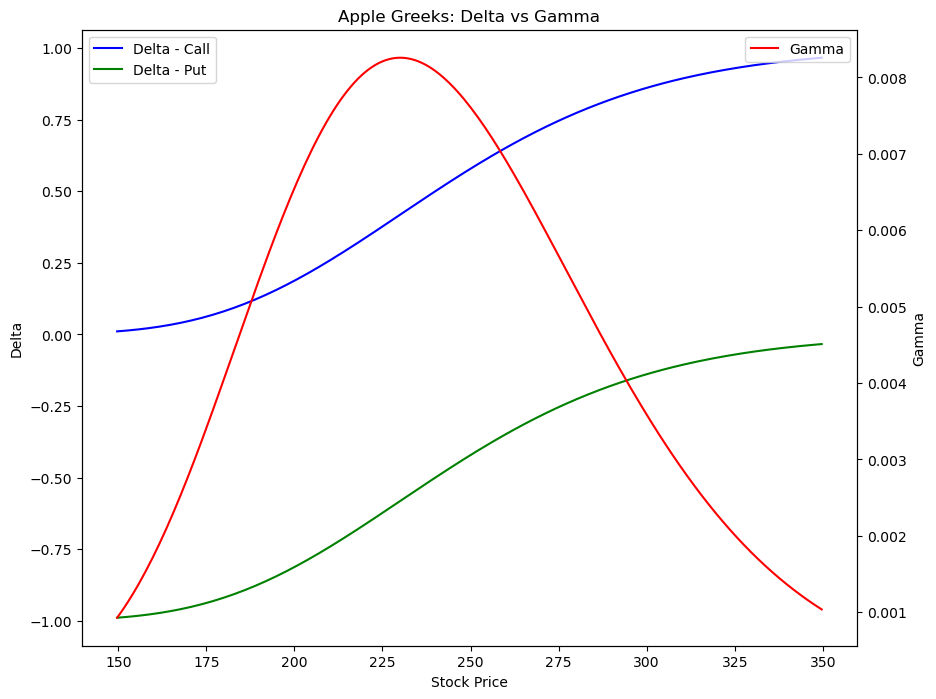

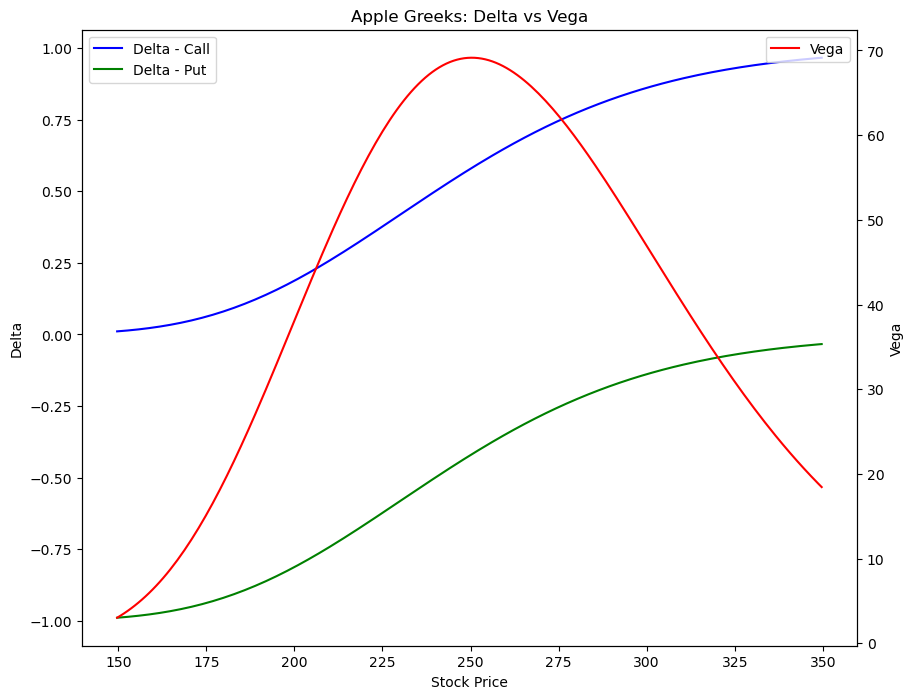

In [25]:
# Plot Apple greek stock-price plots

fig, ax1 = plt.subplots(figsize = (10,8))

ax1.set_ylabel("Delta")
ax1.set_xlabel("Stock Price")
ax1.plot(aapl_greek_prices, aapl_greeks_plot_data["Delta - Call"], color = "blue", label = "Delta - Call")
ax1.plot(aapl_greek_prices, aapl_greeks_plot_data["Delta - Put"], color = "green", label = "Delta - Put")
plt.legend()

ax2 = ax1.twinx()
ax2.set_ylabel("Gamma")
ax2.plot(aapl_greek_prices, aapl_greeks_plot_data["Gamma"], color = "red", label = "Gamma")
plt.legend()
plt.title("Apple Greeks: Delta vs Gamma")
plt.show()


fig, ax1 = plt.subplots(figsize = (10,8))

ax1.set_ylabel("Delta")
ax1.set_xlabel("Stock Price")
ax1.plot(aapl_greek_prices, aapl_greeks_plot_data["Delta - Call"], color = "blue", label = "Delta - Call")
ax1.plot(aapl_greek_prices, aapl_greeks_plot_data["Delta - Put"], color = "green", label = "Delta - Put")
plt.legend()

ax2 = ax1.twinx()
ax2.set_ylabel("Vega")
ax2.plot(aapl_greek_prices, aapl_greeks_plot_data["Vega"], color = "red", label = "Vega")
plt.legend()
plt.title("Apple Greeks: Delta vs Vega")
plt.show()

Apple's Delta traces the expected S-curve, rising from near 0 to near 1 as the stock price moves from deep out-of-the-money to deep in-the-money. Gamma and Vega both peak sharply near the strike price, where the option's eventual payoff is most uncertain, and taper off quickly on either side.

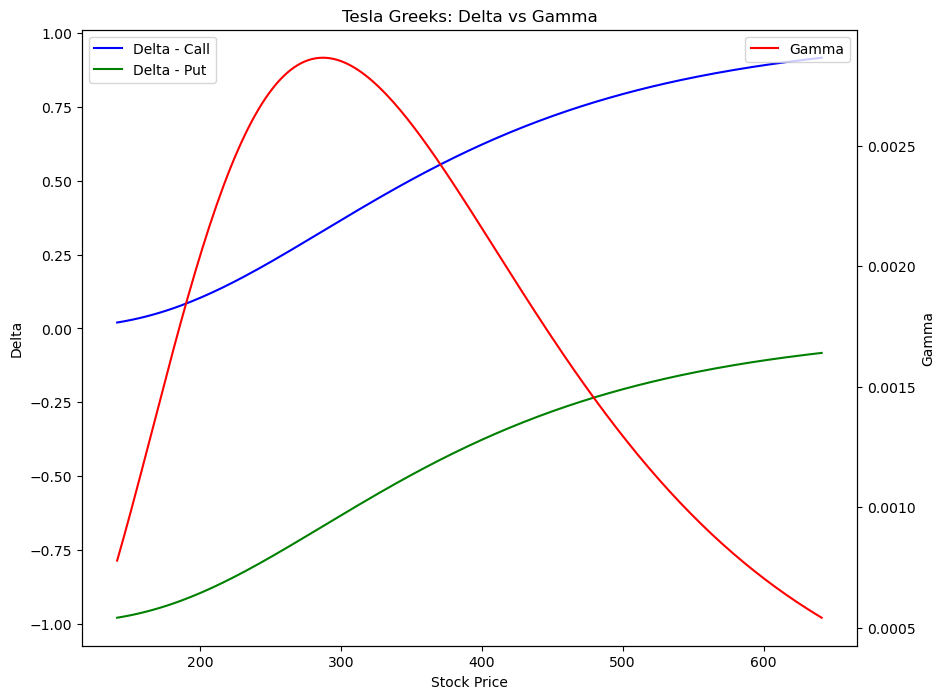

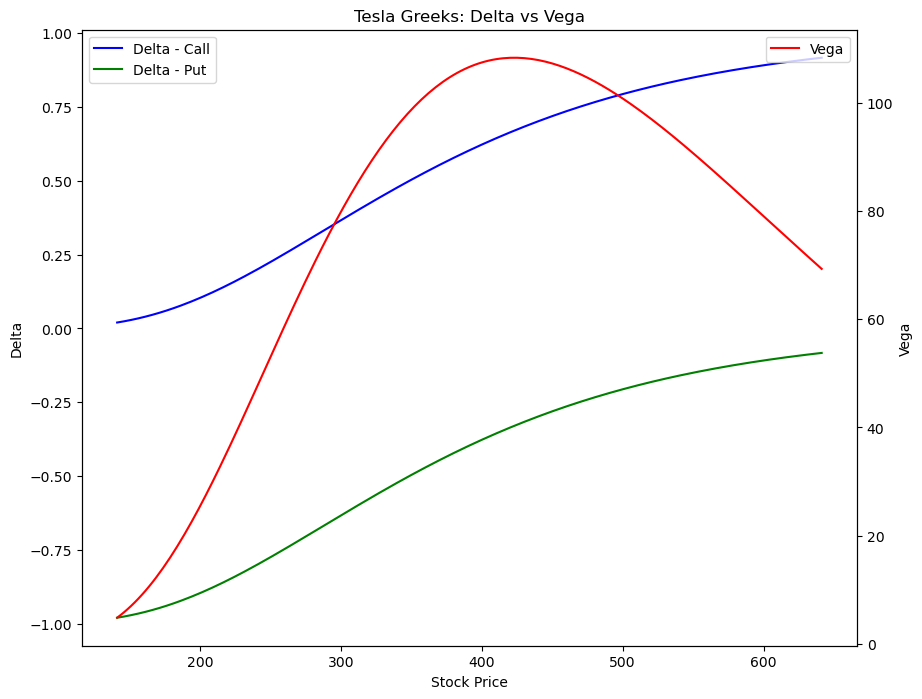

In [26]:
# Plot Tesla greek stock-price plots

# Plotting Delta against Gamma 

fig, ax1 = plt.subplots(figsize = (10,8))

ax1.set_ylabel("Delta")
ax1.set_xlabel("Stock Price")
ax1.plot(tsla_greek_prices, tsla_greeks_plot_data["Delta - Call"], color = "blue", label = "Delta - Call")
ax1.plot(tsla_greek_prices, tsla_greeks_plot_data["Delta - Put"], color = "green", label = "Delta - Put")
plt.legend()

ax2 = ax1.twinx()
ax2.set_ylabel("Gamma")
ax2.plot(tsla_greek_prices, tsla_greeks_plot_data["Gamma"], color = "red", label = "Gamma")
plt.legend()
plt.title("Tesla Greeks: Delta vs Gamma")
plt.show()


# Plotting Delta against Vega

fig, ax1 = plt.subplots(figsize = (10,8))

ax1.set_ylabel("Delta")
ax1.set_xlabel("Stock Price")
ax1.plot(tsla_greek_prices, tsla_greeks_plot_data["Delta - Call"], color = "blue", label = "Delta - Call")
ax1.plot(tsla_greek_prices, tsla_greeks_plot_data["Delta - Put"], color = "green", label = "Delta - Put")
plt.legend()

ax2 = ax1.twinx()
ax2.set_ylabel("Vega")
ax2.plot(tsla_greek_prices, tsla_greeks_plot_data["Vega"], color = "red", label = "Vega")
plt.legend()
plt.title("Tesla Greeks: Delta vs Vega")
plt.show()

Tesla's Delta shows the same S-curve shape, but its Gamma and Vega peaks are visibly flatter and wider than Apple's. This reflects Tesla's higher volatility: with a wider spread of plausible future prices, sensitivity to the stock price and to volatility itself is distributed across a broader range, rather than concentrated tightly around the strike.

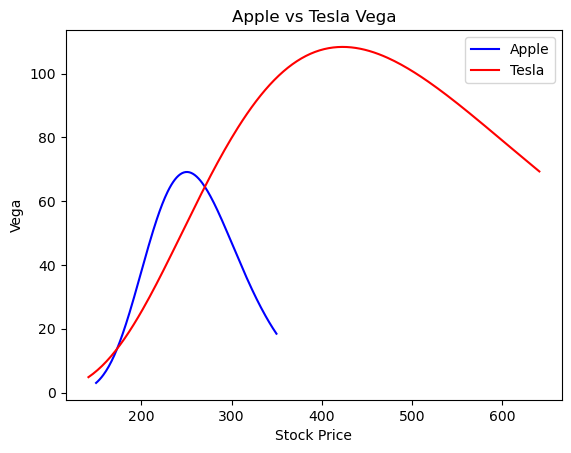

In [27]:
# Plotting Apple and Tesla Vega on one graph

plt.plot(figsize = (10, 10))
plt.plot(aapl_greek_prices, aapl_greeks_plot_data["Vega"], color = "blue", label = "Apple")
plt.plot(tsla_greek_prices, tsla_greeks_plot_data["Vega"], color = "red", label = "Tesla")
plt.ylabel("Vega")
plt.xlabel("Stock Price")
plt.title("Apple vs Tesla Vega")
plt.legend()
plt.show()

This comparison makes the volatility effect explicit: Apple's narrower, taller Vega curve reflects a stock whose outcome is more tightly determined by where it sits relative to the strike, while Tesla's broader, flatter curve reflects genuinely greater uncertainty spread across a wider range of possible prices - directly consistent with the volatility estimates calculated at the start of this project.